In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('STUDENTS.csv')
df.head()

,study_hrs,prev_score,sleep_hrs,ques_paper,perf_index
0,7,99,9,1,91.0
1,4,82,4,2,65.0
2,8,51,7,2,45.0
3,5,52,5,2,36.0
4,7,75,8,5,66.0


In [4]:
x = df.iloc[:, 0:4]
y = df.iloc[:, -1]

x = (x - x.mean()) / x.std()
y = (y - y.mean()) / y.std()

In [5]:
# sklearn for comaprison
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

# data split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=2)

# model trian
lr = LinearRegression()
lr.fit(x_train, y_train)
# predictions
y_pred_sk = lr.predict(x_test)

# evaluation
r2_sc_sk = r2_score(y_test, y_pred_sk)

print('r2_score_sk =',r2_sc_sk)
print('intercept =',lr.intercept_)
print('coef =',lr.coef_)

r2_score_sk = 0.9887873065706716
intercept = 0.00034171958509645033
coef = [0.38457423 0.92049294 0.04225189 0.02969702]


In [6]:
# custom class for stochastic gradient descent
class sto_gd:
    def __init__(self, learning_rate, epochs):   # constructor   
        self.intercept_ = None
        self.coef_ = None
        self.loss_list = []
        self.n = learning_rate
        self.epochs = epochs
    
    def fit(self, x_train, y_train):        # train function
        # random init
        self.intercept_ = 0
        self.coef_ = np.ones(x_train.shape[1])

        for i in range(self.epochs):        # looping through steps
            for j in range(x_train.shape[0]):
                idx = np.random.randint(0, x_train.shape[0])

                y_pred = self.intercept_ + np.dot(x_train[idx], self.coef_) # A scalar(number)

                # update intercept
                grad_intercept = (-2) * (y_train[idx] - y_pred)
                self.intercept_ -= (self.n * grad_intercept)

                # update coef
                grad_coef = (-2) * (y_train[idx] - y_pred) * x_train[idx]
                self.coef_ -= (self.n * grad_coef)
            
            prediction = self.intercept_ + np.dot(x_train, self.coef_)
            loss = np.mean((y_train - prediction)**2)
            self.loss_list.append(loss)
            print(f'step {i} | loss = {loss}')
        
        
        print('intercept = ',self.intercept_)
        print('coef = ',self.coef_)
    
    def predict(self, x_test):
        return self.intercept_ + np.dot(x_test, self.coef_)        

In [7]:
x_train = x_train.values
y_train = y_train.values

In [15]:
import time
start = time.time()
sgd = sto_gd(0.04, 200)
sgd.fit(x_train, y_train)
print('\n Time taken to train: ', time.time() - start)

step 0 | loss = 0.012242648892362566
step 1 | loss = 0.012108995566197532
step 2 | loss = 0.012170516055199051
step 3 | loss = 0.014780727072650652
step 4 | loss = 0.015316587330534629
step 5 | loss = 0.014623431069461297
step 6 | loss = 0.014593735223660318
step 7 | loss = 0.01401601479566877
step 8 | loss = 0.015565228822922935
step 9 | loss = 0.01987530446096838
step 10 | loss = 0.013043810570363891
step 11 | loss = 0.01641944761689284
step 12 | loss = 0.013047257902115254
step 13 | loss = 0.021363825377018128
step 14 | loss = 0.013964270746999491
step 15 | loss = 0.013838748709613888
step 16 | loss = 0.013419137868928002
step 17 | loss = 0.017541672135805274
step 18 | loss = 0.014039098602213994
step 19 | loss = 0.013505753656494864
step 20 | loss = 0.013082718699673862
step 21 | loss = 0.016292428823902697
step 22 | loss = 0.014563610583604909
step 23 | loss = 0.015788263601308097
step 24 | loss = 0.013800306517850594
step 25 | loss = 0.01755302091315154
step 26 | loss = 0.0126949

In [16]:
y_pred_cc = sgd.predict(x_test)
r2_sc_cc = r2_score(y_test, y_pred_cc)
r2_sc_cc

0.9881936223274153

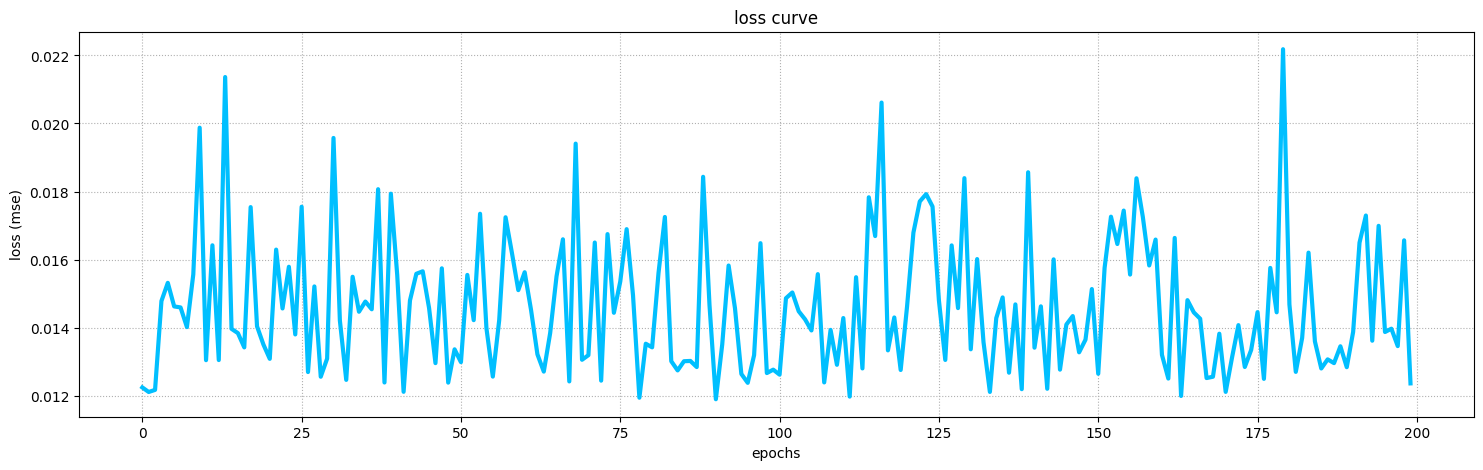

In [19]:
plt.figure(figsize=(18,5))
plt.plot(range(sgd.epochs), sgd.loss_list, color = 'deepskyblue', lw = 3)
plt.xlabel('epochs')
plt.ylabel('loss (mse)')
plt.title('loss curve')
plt.grid(axis = 'both', ls = 'dotted')
plt.show()